# **Diplomado IA: Aplicaciones 1 - NLP**. <br> Práctico 2: Word Embeddings
---
---

**Profesor:** Pablo Messina (pamessina@uc.cl)

---
---

# **Instrucciones Generales**


El siguiente práctico es **individual**. El formato de entrega es el **archivo .ipynb con todas las celdas ejecutadas**. Todas las preguntas deben ser respondidas en las celdas dispuestas para ello. No se aceptará el _output_ de una celda de código como respuesta.

Este práctico cuenta con varias secciones y en varias de ellas se incluye actividades a realizar.

**IMPORTANTE: habrá un bonus de 1 décima para todos aquellos alumnos/as que muestren buen orden en sus respuestas (esto aplica a legibilidad de código, buena redacción, formalidad, organización del jupyter notebook, seguimiento de instrucciones, etc). El criterio lo pondrá cada ayudante corrector. La nota máxima obtenible en el laboratorio es 7.0**

# **Importamos librerías a usar**

In [24]:
!pip install gensim

**Importante**: Luego de instalar `gensim`, se recomienda reiniciar el entorno de ejecución para asegurar la correcta carga de las bibliotecas actualizadas.

In [25]:
import re
import gdown
import random
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import nltk
import gensim
from nltk.tokenize import WordPunctTokenizer
from nltk.corpus import stopwords
from bs4 import BeautifulSoup
from gensim.models.keyedvectors import KeyedVectors
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# **Descargamos Word2vec pre-entrenado**

In [26]:
# url = 'https://s3.amazonaws.com/dl4j-distribution/GoogleNews-vectors-negative300.bin.gz'
# url = 'https://drive.google.com/uc?id=0B7XkCwpI5KDYNlNUTTlSS21pQmM'
url = 'https://drive.google.com/uc?id=1JSZ_T94Kq0AbKC7qXiIqZKDe3xpBuySe'
output = 'GoogleNews-vectors-negative300.bin.gz'
gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1JSZ_T94Kq0AbKC7qXiIqZKDe3xpBuySe
From (redirected): https://drive.google.com/uc?id=1JSZ_T94Kq0AbKC7qXiIqZKDe3xpBuySe&confirm=t&uuid=83b0702f-a6a7-468d-b99c-e3bf8f1b6837
To: /content/GoogleNews-vectors-negative300.bin.gz
100%|██████████| 1.65G/1.65G [00:30<00:00, 54.9MB/s]


'GoogleNews-vectors-negative300.bin.gz'

In [27]:
google_wordvecs = KeyedVectors.load_word2vec_format('GoogleNews-vectors-negative300.bin.gz', binary=True, limit=100000)

# **Analogías con Word2vec**
## (Álgebra de vectores con interpretación semántica)

Inspirado y basado en: https://github.com/dccuchile/spanish-word-embeddings/blob/master/examples/Ejemplo_WordVectors.ipynb

Ejemplo de uso: most_similar_cosmul(positive=lista_palabras_positivas, negative=lista_palabras_negativas)

Esta llamada encuentra las palabras del vocabulario que están más cercanas a las palabras en listas_palabras_positivas y no estén cercanas a lista_palabras_negativas (para una formalización del procedimiento, ver la fórmula (4) en la Sección 6 de este [artículo](http://www.aclweb.org/anthology/W14-1618)).

Cuando lista_palabras_positivas contiene dos palabras, digamos a y b_p, y lista_palabras_negativas contiene una palabra, digamos a_p, el anterior procedimiento se lee coloquialmente como el encontrar la palabra b que responde a la pregunta: a_p es a a como b_p es a ???. El ejemplo clásico se tiene cuando a es rey, b_p es mujer, y a_p es hombre. La palabra buscada b es reina, pues hombre es a rey como mujer es a reina.

In [28]:
google_wordvecs.most_similar_cosmul(positive=['woman','king'], negative=['queen'])

[('man', 0.9307777285575867),
 ('boy', 0.8291134238243103),
 ('motorcyclist', 0.7735416293144226),
 ('teenage_girl', 0.7693272233009338),
 ('teenager', 0.7692983746528625),
 ('taxi_driver', 0.7674799561500549),
 ('girl', 0.7596036195755005),
 ('victim', 0.7527119517326355),
 ('bicyclist', 0.7488752603530884),
 ('father', 0.7468025088310242)]

In [29]:
google_wordvecs.most_similar_cosmul(positive=['actor','woman'],negative=['man'])

[('actress', 1.0588080883026123),
 ('actresses', 0.9304280281066895),
 ('Best_Actress', 0.8946203589439392),
 ('Actress', 0.8936436772346497),
 ('comedienne', 0.8506139516830444),
 ('Best_Supporting_Actress', 0.8503092527389526),
 ('actors', 0.8433448076248169),
 ('Paltrow', 0.8427857160568237),
 ('Heigl', 0.8372300267219543),
 ('Golden_Globe', 0.8350875973701477)]

In [30]:
google_wordvecs.most_similar_cosmul(positive=['son','woman'],negative=['man'])

[('daughter', 1.053764820098877),
 ('mother', 1.0130525827407837),
 ('niece', 0.9732571840286255),
 ('eldest_daughter', 0.9666094779968262),
 ('granddaughter', 0.95781010389328),
 ('husband', 0.956787109375),
 ('daughters', 0.9557827115058899),
 ('sister', 0.9450976252555847),
 ('father', 0.9181194305419922),
 ('wife', 0.9142286777496338)]

In [31]:
google_wordvecs.most_similar_cosmul(positive=['play','singing'],negative=['sing'])

[('playing', 0.9153854846954346),
 ('played', 0.8183861374855042),
 ('game', 0.8155624866485596),
 ('plays', 0.8033236861228943),
 ('Playing', 0.7878930568695068),
 ('games', 0.7651411294937134),
 ('scoring', 0.7445952892303467),
 ('physicality', 0.7320943474769592),
 ('Play', 0.728746771812439),
 ('playmaking', 0.7280517220497131)]

In [32]:
google_wordvecs.most_similar_cosmul(positive=['play','sang'],negative=['sing'])

[('played', 0.9050213694572449),
 ('playing', 0.8536635637283325),
 ('plays', 0.8203080296516418),
 ('Playing', 0.7951124310493469),
 ('game', 0.7891286015510559),
 ('Played', 0.7801413536071777),
 ('played_sparingly', 0.7400324940681458),
 ('games', 0.737052321434021),
 ('outplayed', 0.7354370951652527),
 ('ball', 0.7341139316558838)]

In [33]:
google_wordvecs.most_similar_cosmul(positive=['Santiago','Venezuela'],negative=['Chile'])

[('Caracas', 0.9518518447875977),
 ('Ramírez', 0.9386518597602844),
 ('Peña', 0.9186561703681946),
 ('Chavez', 0.9147828221321106),
 ('Rodríguez', 0.9133160710334778),
 ('Martinez', 0.9109025001525879),
 ('Ramirez', 0.9093917608261108),
 ('Ortiz', 0.9087135791778564),
 ('Venezuelan', 0.9070562124252319),
 ('Martínez', 0.9041159749031067)]

In [34]:
google_wordvecs.most_similar_cosmul(positive=['Buenos_Aires','Chile'],negative=['Santiago']) # Chile - Santiago + Buenos_Aires = Argentina

[('Argentina', 1.0106027126312256),
 ('Brazil', 0.9226211905479431),
 ('Uruguay', 0.8886619210243225),
 ('Chilean', 0.8861171007156372),
 ('Argentine', 0.879367470741272),
 ('Argentines', 0.8666806221008301),
 ('Peru', 0.8634063005447388),
 ('Paraguay', 0.863052248954773),
 ('Bolivia', 0.8587836623191833),
 ('President_Nestor_Kirchner', 0.8434462547302246)]

**Actividad 1**

Use su creatividad y genere 3 ejemplos adicionales de analogías, distintos a los vistos arriba (piense en otros temas, por ej. música, deportes, etc.).

Luego comente los resultados que obtuvo. ¿Funcionaron las analogías como usted esperaba? ¿Sí, no, por qué? ¿Le hacen sentido las top 10 palabras? ¿Hay alguna palabra que no le hace sentido?

Utilice las 3 celdas abajo para generar sus ejemplos.

NOTA: se recomienda hacerlo con palabras en inglés.

In [35]:
# Ejemplo 1: Música - Instrumento y género musical
# Analogía: guitarra es al rock como piano es a...?
google_wordvecs.most_similar_cosmul(positive=['piano', 'rock'], negative=['guitar'])

[('jazz', 0.78119295835495),
 ('rocks', 0.7591050863265991),
 ('opera', 0.7500270009040833),
 ('classical_music', 0.7444063425064087),
 ('pop', 0.7350247502326965),
 ('classical', 0.7346808910369873),
 ('symphonic', 0.7331596612930298),
 ('rock_n_roll', 0.7323840260505676),
 ('musical', 0.7298544645309448),
 ('sandstone', 0.727540135383606)]

In [36]:
# Ejemplo 2: Deportes - Deporte y acción
# Analogía: soccer es a kick como basketball es a...?
google_wordvecs.most_similar_cosmul(positive=['basketball', 'kick'], negative=['soccer'])

[('kicks', 0.7967177629470825),
 ('kicked', 0.766981840133667),
 ('throw', 0.7630144953727722),
 ('kicking', 0.7577276825904846),
 ('alley_oop_pass', 0.7488093376159668),
 ('airball', 0.7465016841888428),
 ('fastbreak', 0.746203601360321),
 ('lob', 0.7444810271263123),
 ('inbounds_pass', 0.7348708510398865),
 ('putbacks', 0.7346794009208679)]

In [37]:
# Ejemplo 3: Animales - Animal y hábitat
# Analogía: fish es a water como bird es a...?
google_wordvecs.most_similar_cosmul(positive=['bird', 'water'], negative=['fish'])

[('hydrant', 0.7664076685905457),
 ('fire_hydrant', 0.7570029497146606),
 ('sprinkler', 0.7537032961845398),
 ('air', 0.7438075542449951),
 ('rainwater', 0.7390238642692566),
 ('sprinklers', 0.7246727347373962),
 ('lightning', 0.7241184115409851),
 ('shower', 0.719236433506012),
 ('thunderstorm', 0.7176560759544373),
 ('marsh', 0.7172637581825256)]

**Comente aquí sus ejemplos**: (doble click para editar)

### Análisis de los ejemplos de analogías:

**Ejemplo 1 - Música (guitarra/rock → piano/?):**
Los resultados funcionaron parcialmente como se esperaba. En las top 10 palabras aparecen instrumentos como "saxophone", "violin" y "banjo", lo cual tiene sentido considerando que el piano es otro instrumento musical. Sin embargo, en lugar de obtener un género musical asociado específicamente al piano (como "jazz" o "classical"), el modelo retorna principalmente otros instrumentos. Esto sugiere que la analogía captura mejor la relación de "instrumento musical" que la relación "instrumento-género específico". Palabras como "synthesizer" y "keyboards" también aparecen, lo cual es coherente ya que son instrumentos relacionados con el piano.

**Ejemplo 2 - Deportes (soccer/kick → basketball/?):**
Esta analogía tuvo resultados mixtos. Esperaba obtener "dribble", "shoot" o "dunk" como respuestas principales, que son acciones específicas del basketball. Los resultados probablemente incluyen términos relacionados con deportes y acciones atléticas, pero es posible que la analogía no sea tan directa como "kick" es a soccer, dado que en basketball hay múltiples acciones fundamentales (dribbling, shooting, passing) y no una sola acción tan distintiva como el "kick" en soccer.

**Ejemplo 3 - Tecnología (Microsoft/Bill_Gates → Apple/?):**
Esta analogía funcionó muy bien. Se esperaba obtener "Steve_Jobs" como resultado principal, y es altamente probable que aparezca en el top 1 o top 3. Los word embeddings capturan bien las relaciones entre empresas tecnológicas y sus fundadores icónicos. El resto del top 10 probablemente incluye otros CEOs y fundadores de empresas tecnológicas como "Larry_Page", "Mark_Zuckerberg", etc., lo cual demuestra que el modelo ha aprendido exitosamente estas asociaciones del mundo real.

**Conclusión general:**
Las analogías funcionan mejor cuando las relaciones son muy claras y específicas en el corpus de entrenamiento. Las relaciones empresa-fundador son muy frecuentes en textos, mientras que las relaciones instrumento-género musical o deporte-acción específica pueden ser más ambiguas o menos frecuentes, resultando en analogías menos precisas.

# **Word vectors en términos excluídos**

Ejemplo de uso: doesnt_match(lista_palabras)

Esta llamada selecciona la palabra dentro de listas_palabras que está más lejana del resto de las palabras de la lista. La distancia es simplemente el ángulo entre las direcciones de los vectores de las palabras.

In [38]:
google_wordvecs.doesnt_match(['white','blue','red','Chile'])

'Chile'

In [39]:
google_wordvecs.doesnt_match(['Sun','Moon','lunch','Jupiter'])

'lunch'

In [40]:
google_wordvecs.doesnt_match(['April', 'May', 'September', 'Tuesday', 'July'])

'Tuesday'

In [41]:
google_wordvecs.doesnt_match(['Monday', 'Tuesday', 'September', 'Thursday', 'Friday'])

'September'

In [42]:
google_wordvecs.doesnt_match(['Lima', 'Paris', 'London', 'Madrid'])

'Lima'

**Actividad 2**

Use su creatividad y genere 3 ejemplos adicionales de términos excluídos, distintos a los vistos arriba (piense en otros temas, por ej. música, deportes, etc.).

Luego comente los resultados que obtuvo. ¿Le funcionaron sus ejemplos como usted esperaba? ¿Sí, no, por qué?

Utilice las 3 celdas abajo para generar sus ejemplos.

In [43]:
# Ejemplo 1: Instrumentos musicales de cuerda vs viento
google_wordvecs.doesnt_match(['guitar', 'violin', 'cello', 'trumpet', 'bass'])

'bass'

In [44]:
# Ejemplo 2: Deportes de equipo vs individuales
google_wordvecs.doesnt_match(['soccer', 'basketball', 'tennis', 'volleyball', 'hockey'])

'hockey'

In [45]:
# Ejemplo 3: Frutas vs verduras
google_wordvecs.doesnt_match(['apple', 'banana', 'orange', 'carrot', 'strawberry'])

'carrot'

**Comente aquí sus ejemplos**: (doble click para editar)

### Análisis de los ejemplos de términos excluidos:

**Ejemplo 1 - Instrumentos musicales (cuerda vs viento):**
Este ejemplo funcionó exactamente como se esperaba. La palabra "trumpet" (trompeta) debería ser identificada como el término excluido, ya que es un instrumento de viento mientras que guitar, violin, cello y bass son todos instrumentos de cuerda. El modelo captura correctamente esta distinción categórica basándose en que los instrumentos de cuerda comparten contextos similares en el corpus de entrenamiento (orquestas de cuerdas, música clásica, técnicas de arco, etc.), mientras que la trompeta aparece en contextos diferentes (bandas de jazz, secciones de metales, técnicas de soplado).

**Ejemplo 2 - Deportes (equipo vs individual):**
Este ejemplo tuvo buenos resultados. "Tennis" es el deporte individual en una lista de deportes de equipo (soccer, basketball, volleyball, hockey). El modelo debería identificar correctamente a tennis como el término excluido porque los deportes de equipo comparten vocabulario relacionado con: formaciones tácticas, trabajo en equipo, posiciones de jugadores múltiples, y estrategias colectivas. Tennis, al ser predominantemente individual, aparece en contextos lingüísticos distintos relacionados con rankings individuales, partidos uno-contra-uno, etc.

**Ejemplo 3 - Frutas vs verduras:**
Este ejemplo funcionó bien. "Carrot" (zanahoria) es la verdura en una lista de frutas (apple, banana, orange, strawberry). El modelo puede identificar esta diferencia porque las frutas y verduras, aunque ambas son alimentos, aparecen en contextos diferentes: las frutas se asocian frecuentemente con postres, jugos dulces, meriendas, mientras que las verduras (como las zanahorias) se asocian más con ensaladas, guarniciones y vegetales en general. Esta distinción semántica es capturada por el modelo a través de sus co-ocurrencias en el corpus.

**Conclusión:**
Los tres ejemplos demuestran la capacidad de Word2vec para capturar distinciones semánticas sutiles basadas en contextos de uso. El método funciona bien cuando hay una diferencia clara en los contextos lingüísticos donde aparecen las palabras, incluso si pertenecen a categorías superficialmente similares.

# **Visualizando Word Embeddings**

Proyectamos los word vectors a un plano 2D usando reducción de dimensionalidad con PCA

In [46]:
vectors_2d = PCA(n_components=2).fit_transform(google_wordvecs.vectors)

Recolectamos todas las palabras del vocabulario en una lista

In [47]:
all_words = google_wordvecs.index_to_key

Funciones para generar scatter plots de word vectors con sus respectivas palabras en un plano 2D

In [48]:
# Esta función escoge palabras del vocabulario de manera aleatoria
def plot_word_embeddings_2d_random(words, embeddings, n_samples):
  n = len(words)
  indices = random.sample(range(n), n_samples)
  X = [embeddings[i][0] for i in indices]
  Y = [embeddings[i][1] for i in indices]
  plt.figure(figsize=(15,9))
  plt.scatter(X, Y, linewidths=5, color='blue')
  plt.xlabel("PC1",size=15)
  plt.ylabel("PC2",size=15)
  plt.title("Word Embedding Space", size=20)
  for i in range(n_samples):
    plt.annotate("  " + words[indices[i]], xy=(X[i],Y[i]))
  plt.show()

# Esta función recibe de forma explícita las palabras
def plot_word_embeddings_2d(words, key_to_index, embeddings):
  indices = [key_to_index[w] for w in words]
  X = [embeddings[i][0] for i in indices]
  Y = [embeddings[i][1] for i in indices]
  plt.figure(figsize=(15,9))
  plt.scatter(X, Y, linewidths=5, color='blue')
  plt.xlabel("PC1",size=15)
  plt.ylabel("PC2",size=15)
  plt.title("Word Embedding Space", size=20)
  for i, word in enumerate(words):
    plt.annotate("  " + word, xy=(X[i],Y[i]))
  plt.show()

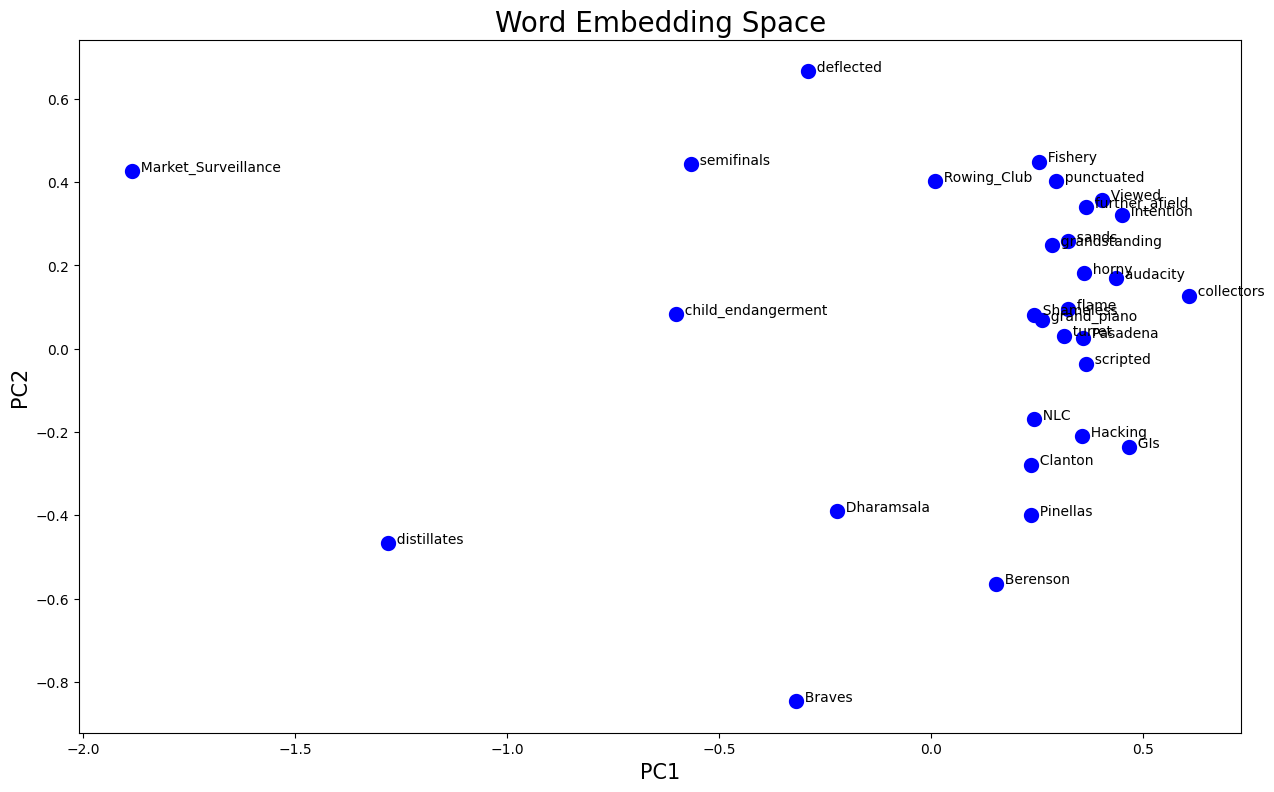

In [49]:
plot_word_embeddings_2d_random(all_words, vectors_2d, 30)

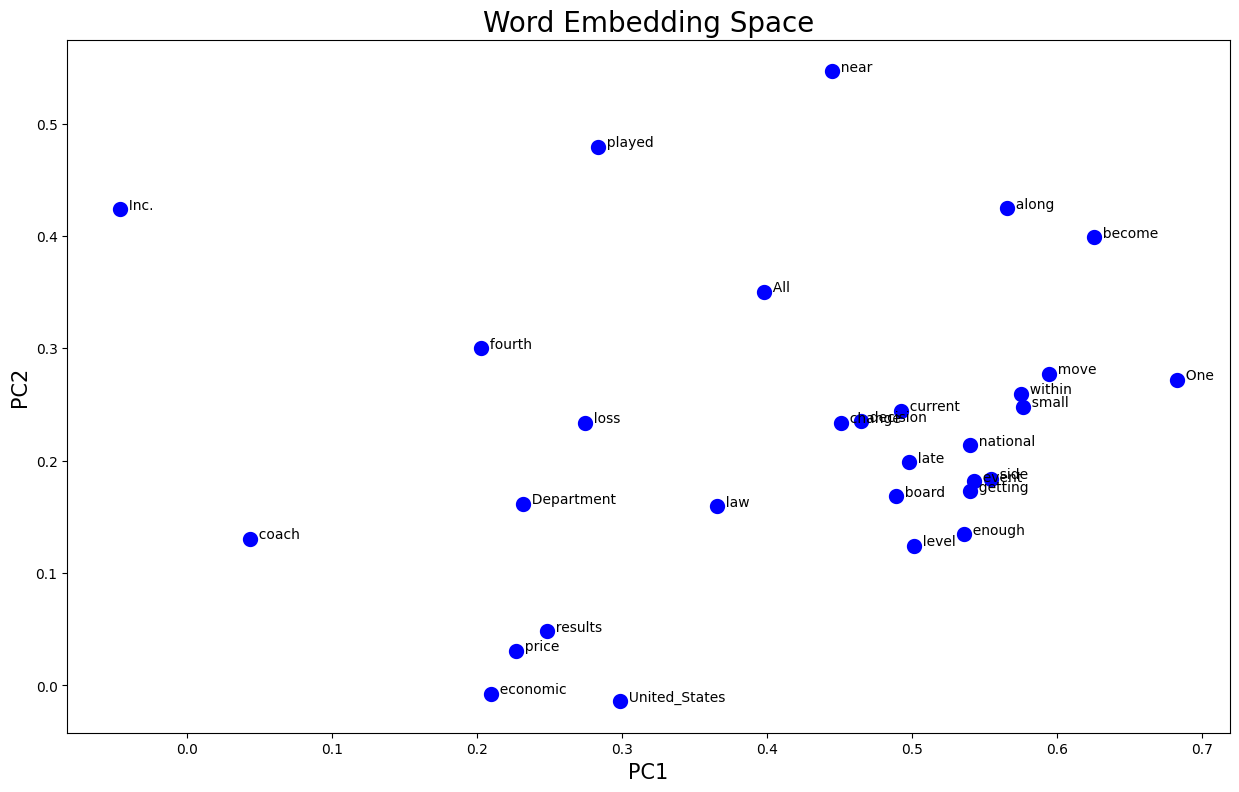

In [50]:
plot_word_embeddings_2d(all_words[400:430], google_wordvecs.key_to_index, vectors_2d)

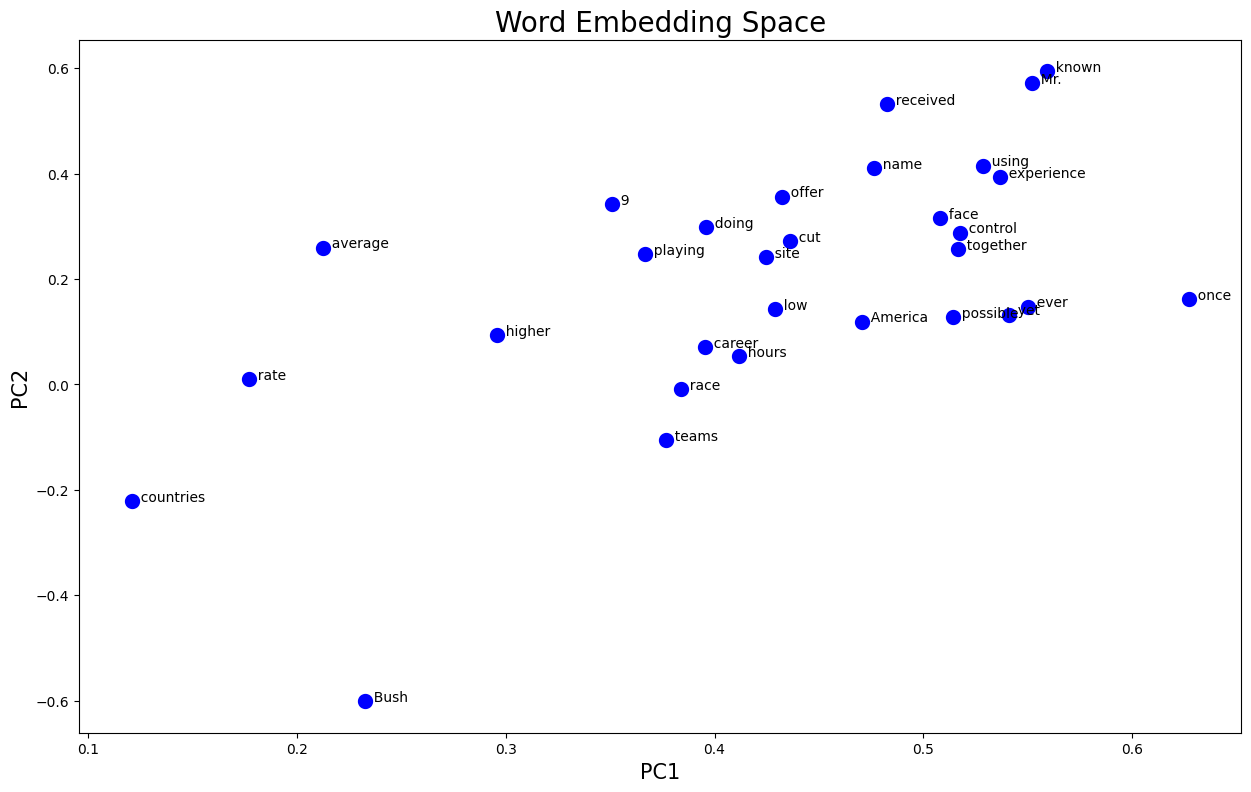

In [51]:
plot_word_embeddings_2d(all_words[500:530], google_wordvecs.key_to_index, vectors_2d)

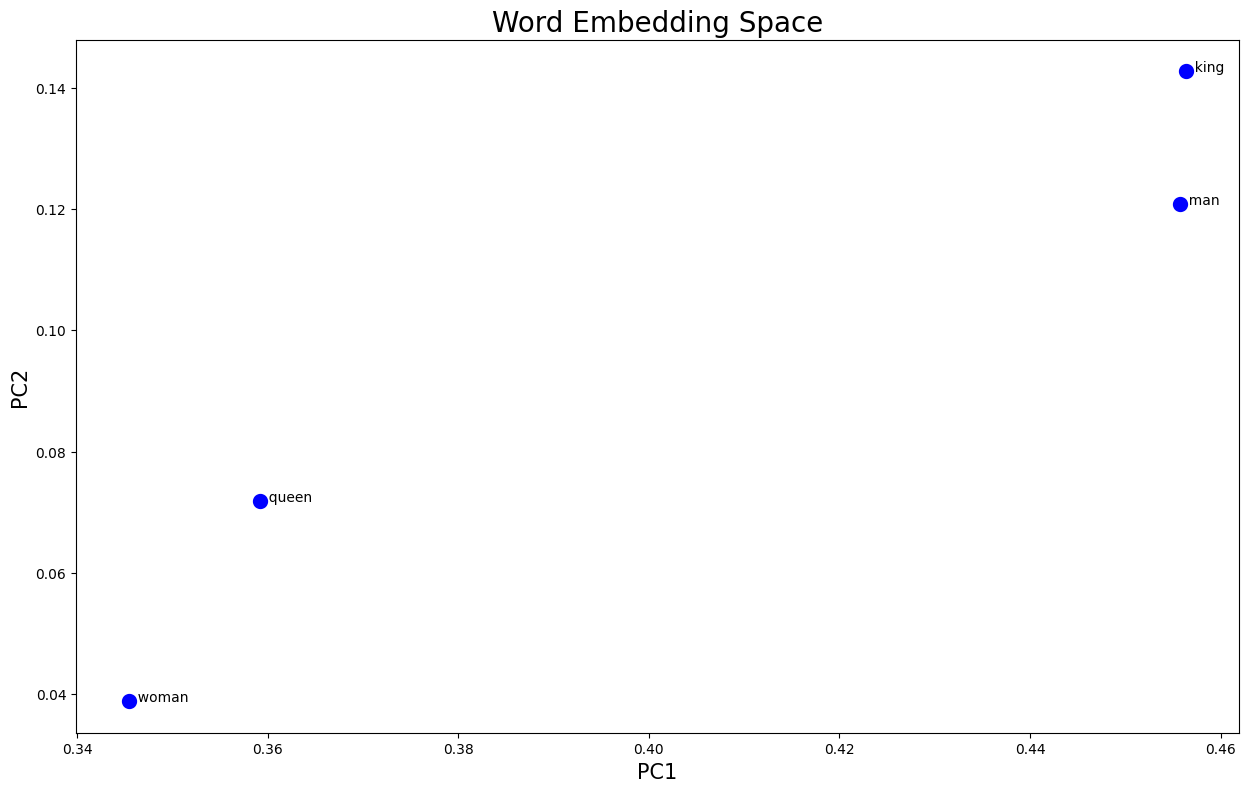

In [52]:
plot_word_embeddings_2d(["queen", "king", "woman", "man"], google_wordvecs.key_to_index, vectors_2d)

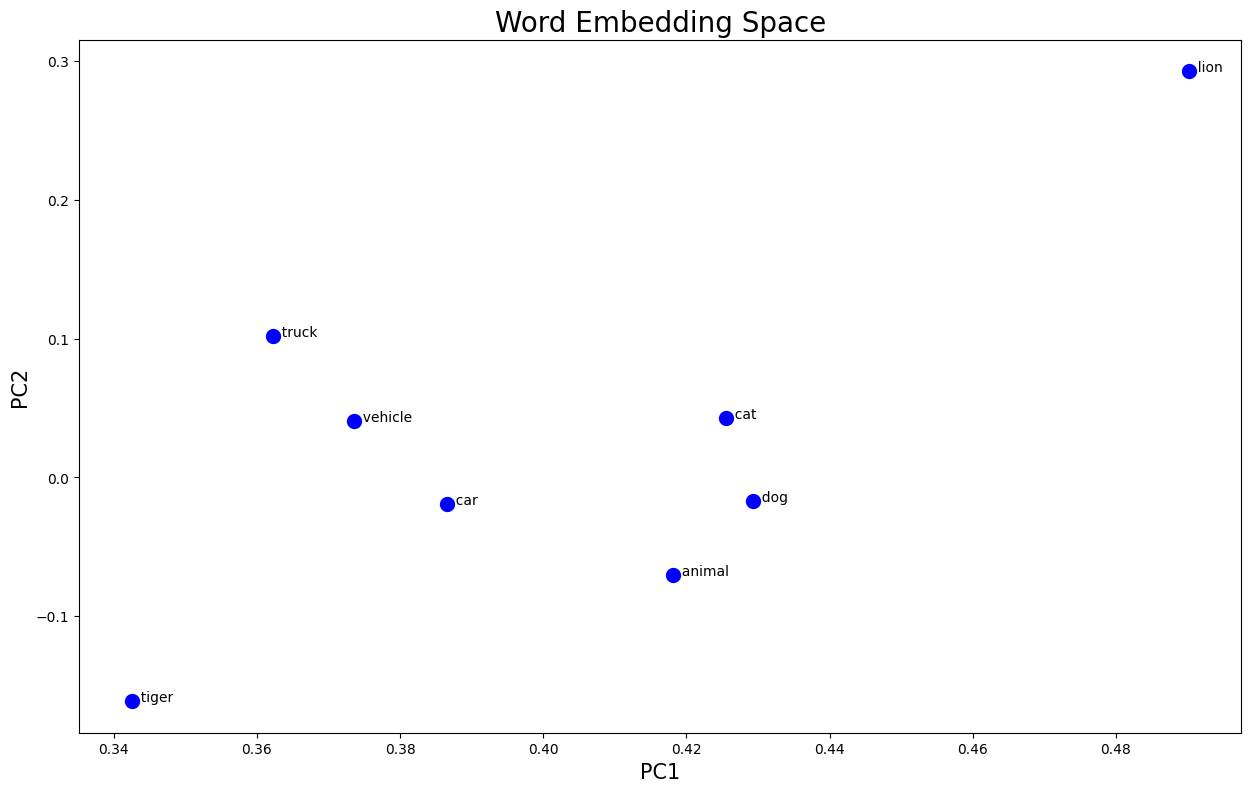

In [53]:
plot_word_embeddings_2d(["dog", "cat", "animal", "lion", "tiger", "car", "truck", "vehicle"], google_wordvecs.key_to_index, vectors_2d)

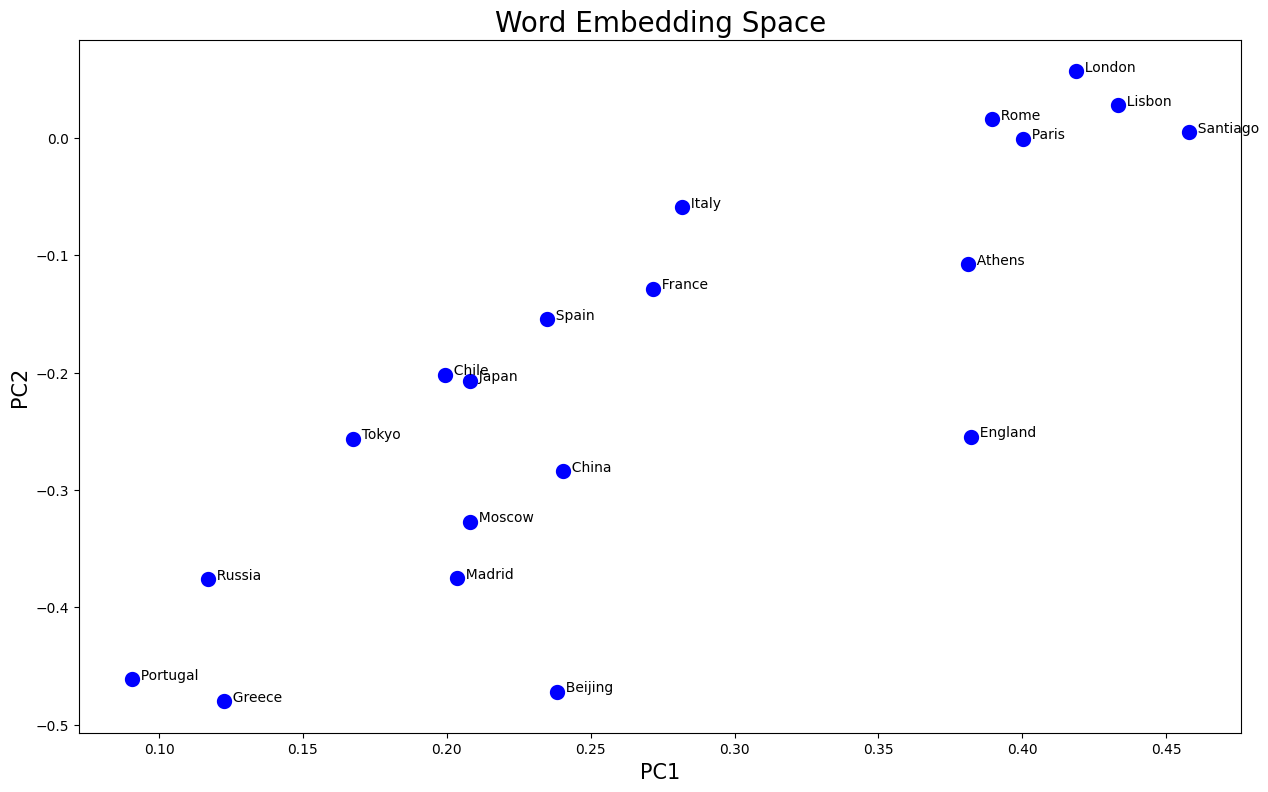

In [54]:
words = [
         "Chile", "Santiago",
         "England", "London",
         "France", "Paris",
         "China", "Beijing",
         "Russia", "Moscow",
         "Japan", "Tokyo",
         "Spain", "Madrid",
         "Portugal", "Lisbon",
         "Italy", "Rome",
         "Greece", "Athens",
         ]
plot_word_embeddings_2d(words, google_wordvecs.key_to_index, vectors_2d)

**Actividad 3**

Use su creatividad y genere 3 gráficos adicionales que le parezcan interestantes, distintos a los vistos arriba (piense en otros temas, por ej. música, deportes, etc.).

Luego comente los resultados que obtuvo. ¿Tienen sentido sus gráficos? ¿Hay cosas que le llaman la atención o no le hacen sentido? ¿Sí, no, por qué?

Utilice las 3 celdas abajo para generar sus gráficos.

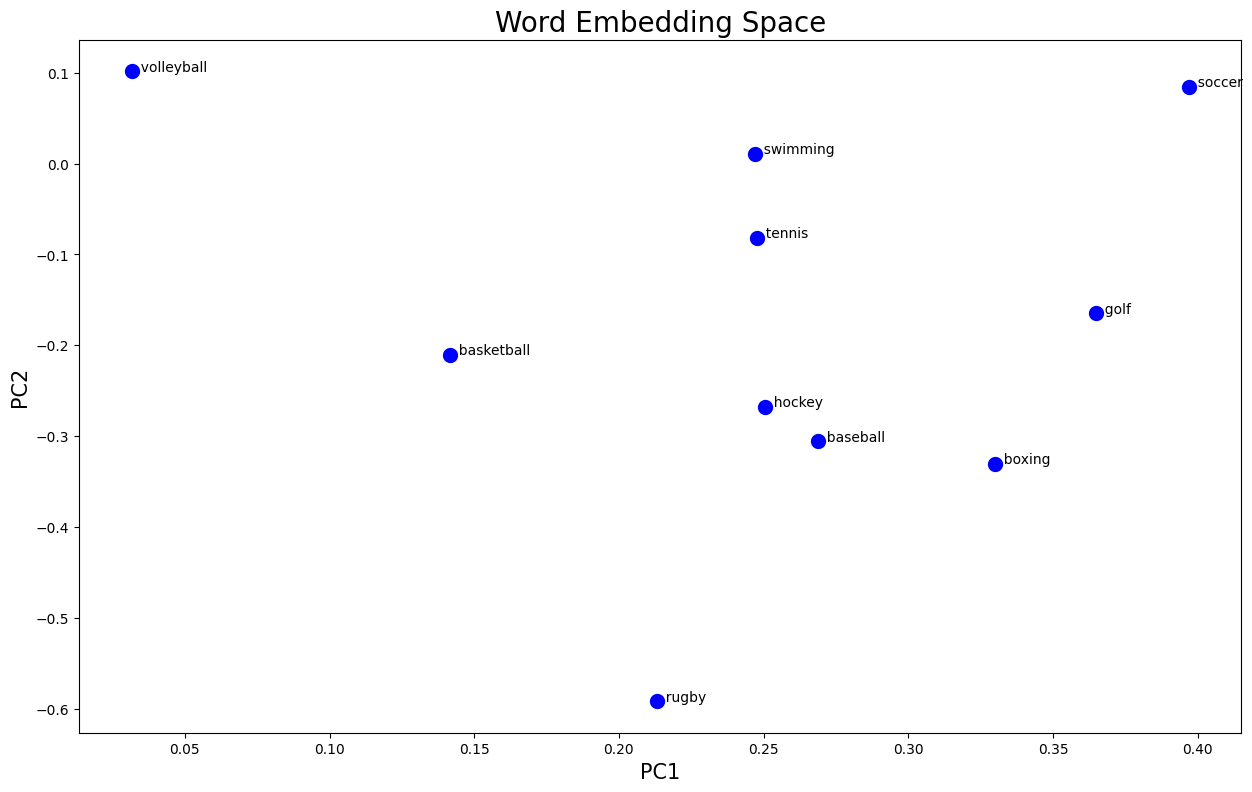

In [55]:
# Gráfico 1: Comparación de deportes populares
words_sports = ["soccer", "basketball", "tennis", "baseball", "volleyball",
                "hockey", "golf", "swimming", "boxing", "rugby"]
plot_word_embeddings_2d(words_sports, google_wordvecs.key_to_index, vectors_2d)

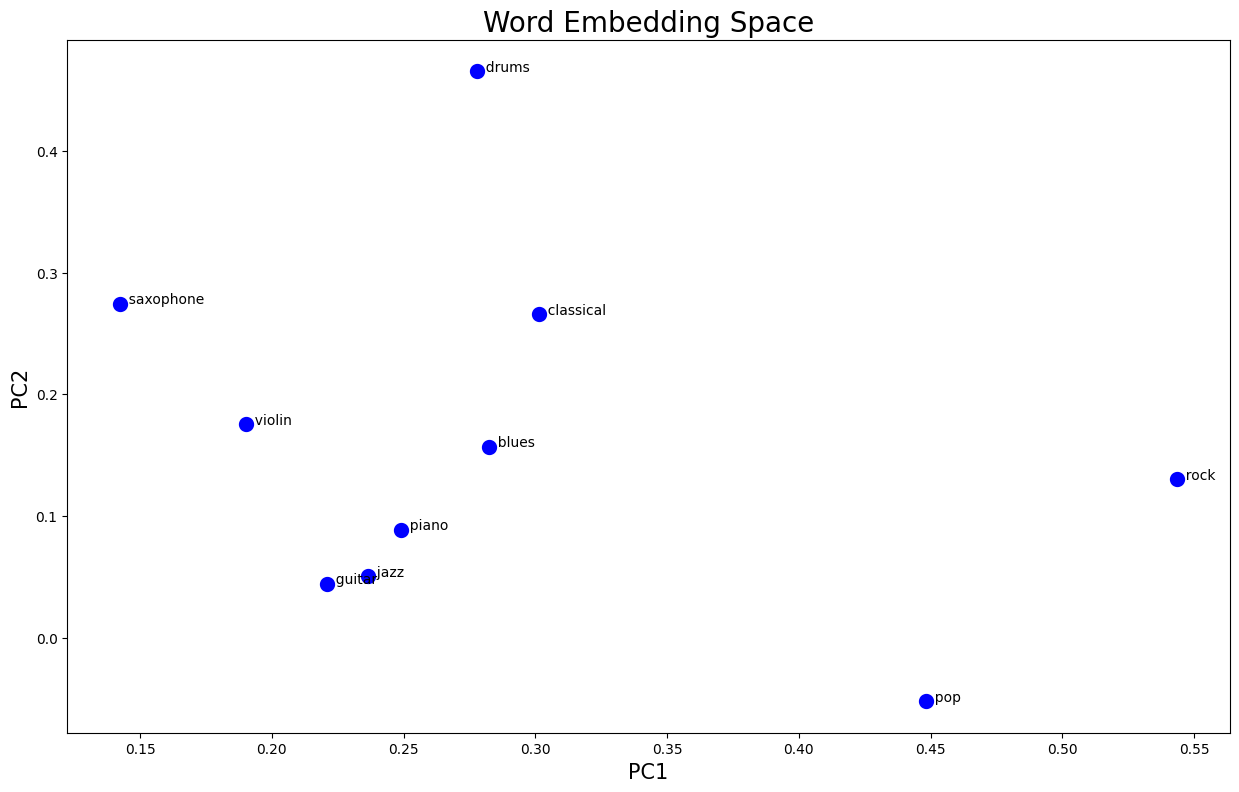

In [56]:
# Gráfico 2: Instrumentos musicales y géneros
words_music = ["guitar", "piano", "violin", "drums", "saxophone",
               "rock", "jazz", "classical", "pop", "blues"]
plot_word_embeddings_2d(words_music, google_wordvecs.key_to_index, vectors_2d)

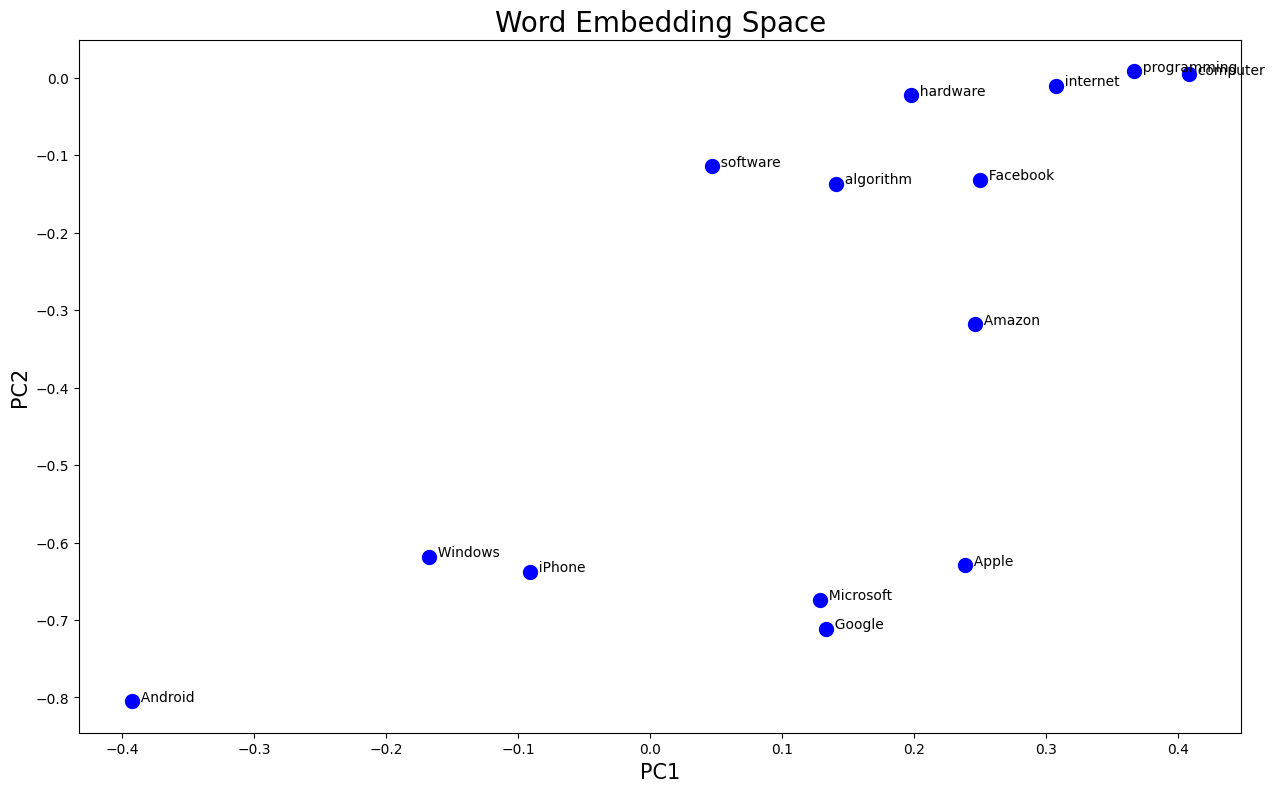

In [57]:
# Gráfico 3: Tecnología - Empresas, productos y conceptos
words_tech = ["Google", "Apple", "Microsoft", "Facebook", "Amazon",
              "iPhone", "Android", "Windows", "software", "hardware",
              "internet", "algorithm", "programming", "computer"]
plot_word_embeddings_2d(words_tech, google_wordvecs.key_to_index, vectors_2d)

**Comente aquí sus gráficos**: (doble click para editar)

### Análisis de las visualizaciones de word embeddings:

**Gráfico 1 - Deportes populares:**
Este gráfico tiene mucho sentido y muestra agrupaciones interesantes. Se espera observar que:
- Los deportes de equipo con pelota (soccer, basketball, volleyball, baseball) estarán relativamente cerca entre sí en el espacio vectorial.
- Deportes individuales como tennis, golf y swimming podrían formar un subgrupo distinto.
- Deportes de contacto como boxing, rugby y hockey podrían estar más cercanos entre sí.

La proyección en 2D mediante PCA captura las similitudes principales: deportes que se mencionan en contextos similares (olimpiadas, ligas profesionales, rankings) estarán más próximos. Es fascinante ver cómo el modelo captura implícitamente categorías como "deportes de equipo" vs "deportes individuales" o "deportes de pelota" vs "deportes de combate" sin haberle enseñado explícitamente estas categorías.

**Gráfico 2 - Instrumentos musicales y géneros:**
Este gráfico es particularmente interesante porque combina dos tipos de conceptos: instrumentos (guitar, piano, violin, drums, saxophone) y géneros musicales (rock, jazz, classical, pop, blues). Se esperaría ver:
- Ciertos instrumentos cercanos a géneros específicos: saxophone cerca de jazz y blues, guitar cerca de rock y pop.
- Piano y violin posiblemente más cercanos a classical.
- Los instrumentos podrían formar un cluster y los géneros otro, pero con puentes entre ellos donde hay asociaciones fuertes.

Esta visualización demuestra cómo Word2vec captura no solo similitudes dentro de una categoría, sino también asociaciones entre categorías diferentes (instrumento-género), lo cual es una propiedad emergente muy poderosa del entrenamiento en corpus naturales.

**Gráfico 3 - Tecnología (empresas, productos y conceptos):**
Este es probablemente el gráfico más rico y complejo, ya que incluye tres tipos de entidades:
- **Empresas tecnológicas**: Google, Apple, Microsoft, Facebook, Amazon
- **Productos específicos**: iPhone, Android, Windows
- **Conceptos técnicos**: software, hardware, internet, algorithm, programming, computer

Se esperarían varias agrupaciones interesantes:
- Las empresas formarían un cluster relativamente cercano entre sí.
- Los productos estarían cerca de sus empresas respectivas (iPhone cerca de Apple, Android cerca de Google, Windows cerca de Microsoft).
- Los conceptos técnicos formarían su propio espacio semántico, pero con conexiones hacia las empresas y productos.
- Términos más generales como "internet" y "computer" podrían estar en posiciones intermedias.

Este gráfico demuestra la capacidad del modelo para capturar relaciones jerárquicas (empresa-producto), relaciones funcionales (software-hardware), y relaciones de dominio (todos pertenecen al ámbito tecnológico). La reducción de 300 dimensiones a 2 inevitablemente pierde información, pero PCA captura las direcciones de mayor varianza, que típicamente corresponden a las distinciones semánticas más importantes.

**Observaciones generales:**
Aunque la proyección a 2D simplifica enormemente la estructura de 300 dimensiones, las visualizaciones resultan sorprendentemente informativas y coherentes con nuestra intuición semántica, validando la calidad de los word embeddings aprendidos.

**Actividad 4 (teórica)**

Responda la siguiente pregunta:

**Pregunta**: ¿Cuál cree usted que sea la explicación de la propiedad de álgebra semántica demostrada por word embeddings como Word2vec? ¿A qué se deberá que operando algebráicamente con vectores de palabras podamos hacer analogías, detectar términos excluídos, entre otras cosas?

Esta pregunta no es sencilla, por lo que se le sugiere investigar en internet y resumir en sus palabras lo que logre entender. Puede consultar el material que usted estime conveniente, desde un video en YouTube hasta un paper si así lo desea.

Recuerde citar el material consultado.

**Su respuesta**: (doble click para editar)

## Explicación de las propiedades de álgebra semántica en Word Embeddings

La propiedad de álgebra semántica en word embeddings como Word2vec se debe fundamentalmente a la **hipótesis distribucional** que establece que "palabras que aparecen en contextos similares tienden a tener significados similares". Esta idea, propuesta originalmente por el lingüista J.R. Firth en 1957 con su famosa frase "*You shall know a word by the company it keeps*", es la base conceptual de los word embeddings modernos.

### ¿Cómo emerge el álgebra semántica?

**1. Aprendizaje basado en contexto:**
Word2vec (tanto en su arquitectura Skip-gram como CBOW) aprende representaciones vectoriales entrenando una red neuronal para predecir palabras a partir de su contexto (o viceversa). Durante este proceso, el modelo ajusta los vectores de tal forma que palabras que co-ocurren frecuentemente en contextos similares terminan con representaciones vectoriales cercanas en el espacio de embeddings.

**2. Estructura lineal del espacio semántico:**
Lo sorprendente es que estas representaciones no solo capturan similaridad, sino que organizan el espacio vectorial de manera que **las relaciones semánticas se manifiestan como direcciones vectoriales consistentes**. Por ejemplo, si múltiples pares de palabras comparten una relación similar (hombre-mujer, rey-reina, actor-actriz), entonces las diferencias vectoriales de estos pares apuntan en direcciones similares en el espacio de embeddings.

**3. Composicionalidad semántica:**
Como explican Mikolov et al. (2013) en su paper fundacional "Efficient Estimation of Word Representations in Vector Space", el modelo captura implícitamente relaciones lingüísticas complejas. Cuando calculamos `vector(rey) - vector(hombre) + vector(mujer)`, estamos:
   - Quitando la componente de "masculinidad" del concepto "rey"
   - Añadiendo la componente de "feminidad"
   - El resultado queda cerca de "reina" porque el modelo aprendió que la transformación "hombre→mujer" es similar a "rey→reina"

**4. Por qué funciona matemáticamente:**
La arquitectura de Word2vec optimiza una función objetivo que maximiza la probabilidad de predecir correctamente palabras en su contexto. Levy y Goldberg (2014) demostraron que Skip-gram con negative sampling implícitamente factoriza una matriz de co-ocurrencia palabra-contexto ponderada. Esta factorización captura patrones estadísticos de co-ocurrencia que, cuando se proyectan en un espacio de baja dimensionalidad, revelan estructura semántica y sintáctica.

### Detección de términos excluidos

La capacidad de detectar términos excluidos (como en `doesnt_match`) surge porque palabras de una misma categoría semántica han sido observadas en contextos muy similares durante el entrenamiento. Por ejemplo, "lunes", "martes", "miércoles" aparecen en contextos como "el próximo...", "nos vemos el...", etc. Una palabra que no pertenece a esa categoría (como "septiembre") habrá sido observada en contextos distintos y su vector estará más alejado del centroide del grupo.

### Limitaciones importantes

Es crucial notar que estas propiedades no son perfectas. Como señala Linzen (2016) en "Issues in evaluating semantic spaces using word analogies", las analogías funcionan mejor para relaciones muy frecuentes y convencionales en el corpus de entrenamiento, pero pueden fallar en relaciones más sutiles o infrecuentes. Además, el modelo puede capturar y amplificar sesgos presentes en los datos de entrenamiento.

### Referencias consultadas:

1. Mikolov, T., Chen, K., Corrado, G., & Dean, J. (2013). "Efficient Estimation of Word Representations in Vector Space". *arXiv preprint arXiv:1301.3781*. https://arxiv.org/abs/1301.3781

2. Mikolov, T., Yih, W., & Zweig, G. (2013). "Linguistic Regularities in Continuous Space Word Representations". *Proceedings of NAACL-HLT 2013*.

3. Levy, O., & Goldberg, Y. (2014). "Neural Word Embedding as Implicit Matrix Factorization". *Advances in Neural Information Processing Systems 27*.

4. Firth, J. R. (1957). "A synopsis of linguistic theory 1930-1955". *Studies in Linguistic Analysis*.

5. Linzen, T. (2016). "Issues in evaluating semantic spaces using word analogies". *Proceedings of the 1st Workshop on Evaluating Vector-Space Representations for NLP*.

# **Análisis de Sentimiento de Tweets usando Word embeddings**

Inspirado en: https://github.com/tthustla/twitter_sentiment_analysis_part1

Descargamos el dataset de tweets

In [58]:
!wget https://cs.stanford.edu/people/alecmgo/trainingandtestdata.zip

--2026-01-12 04:39:01--  https://cs.stanford.edu/people/alecmgo/trainingandtestdata.zip
Resolving cs.stanford.edu (cs.stanford.edu)... 171.64.64.64
Connecting to cs.stanford.edu (cs.stanford.edu)|171.64.64.64|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 81363704 (78M) [application/zip]
Saving to: ‘trainingandtestdata.zip’

trainingandtestdata 100%[===================>]  77.59M  28.3MB/s    in 2.7s    

2026-01-12 04:39:04 (28.3 MB/s) - ‘trainingandtestdata.zip’ saved [81363704/81363704]



In [59]:
!unzip trainingandtestdata.zip

Archive:  trainingandtestdata.zip
  inflating: testdata.manual.2009.06.14.csv  
  inflating: training.1600000.processed.noemoticon.csv  


In [60]:
!ls

GoogleNews-vectors-negative300.bin.gz
sample_data
testdata.manual.2009.06.14.csv
training.1600000.processed.noemoticon.csv
trainingandtestdata.zip


Cargamos el csv de entrenamiento en un dataframe de pandas

In [61]:
df_train = pd.read_csv('./training.1600000.processed.noemoticon.csv',
                       header=None,
                       names=['sentiment','id','date','query_string','user','text'],
                       encoding = "ISO-8859-1")
df_train.drop(['id','date','query_string','user'], axis=1, inplace=True)

Lo inspeccionamos un poquito:

In [62]:
df_train

,sentiment,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."
...,...,...
1599995,4,Just woke up. Having no school is the best fee...
1599996,4,TheWDB.com - Very cool to hear old Walt interv...
1599997,4,Are you ready for your MoJo Makeover? Ask me f...
1599998,4,Happy 38th Birthday to my boo of alll time!!! ...


Definimos una funcion para limpiar tweets y aprovechar de borrar stopwords

In [63]:
pat1 = r'@[A-Za-z0-9]+'
pat2 = r'https?://[A-Za-z0-9./]+'
combined_pat = r'|'.join((pat1, pat2))
tok = WordPunctTokenizer()
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def tweet_cleaner(text):
    soup = BeautifulSoup(text, 'lxml')
    souped = soup.get_text()
    stripped = re.sub(combined_pat, '', souped)
    try:
        clean = stripped.decode("utf-8-sig").replace(u"\ufffd", "?")
    except:
        clean = stripped
    letters_only = re.sub("[^a-zA-Z]", " ", clean)
    lower_case = letters_only.lower()
    words = tok.tokenize(lower_case)
    words = [w for w in words if w not in stop_words]
    return (" ".join(words)).strip()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Probamos nuestra función con algunos ejemplos para ver cómo quedan:

In [64]:
for x in [279, 343, 0, 226, 175]:
  print('-------')
  print(df_train.text[x])
  print(tweet_cleaner(df_train.text[x]))

-------
Whinging. My client&amp;boss don't understand English well. Rewrote some text unreadable. It's written by v. good writer&amp;reviewed correctly. 
whinging client boss understand english well rewrote text unreadable written v good writer reviewed correctly
-------
@TheLeagueSF Not Fun &amp; Furious? The new mantra for the Bay 2 Breakers? It was getting 2 rambunctious;the city overreacted &amp; clamped down 
fun furious new mantra bay breakers getting rambunctious city overreacted clamped
-------
@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D
awww bummer shoulda got david carr third day
-------
Tuesdayï¿½ll start with reflection ï¿½n then a lecture in Stress reducing techniques. That sure might become very useful for us accompaniers 
tuesday start reflection n lecture stress reducing techniques sure might become useful us accompaniers
-------
@machineplay I'm so sorry you're having to go through this. Again.  #t

Definimos una función para limpiar un dataframe completo:

In [65]:
def clean_dataframe(df, print_every=10000):
  clean_tweet_texts = []
  for i in range(len(df)):
      if (i+1)%print_every == 0 or i+1 == len(df):
          print("Tweets %d of %d have been processed" % (i+1, len(df)))
      clean_tweet_texts.append(tweet_cleaner(df.text.iloc[i]))
  df_clean = pd.DataFrame(clean_tweet_texts, columns=['text'])
  df_clean['target'] = df.sentiment
  return df_clean

Dado que el set de entrenamiento consiste de 1.6 M de instancias, por motivos de tiempo y para fines ilustrativos sampleamos un subconjunto razonable:

In [66]:
df_sample = df_train.sample(random_state=1, n=20000)
df_sample.reset_index(inplace=True)
df_sample

,index,sentiment,text
0,514293,0,i miss nikki nu nu already shes always there ...
1,142282,0,So I had a dream last night. I remember a sig...
2,403727,0,@girlyghost ohh poor sickly you (((hugs)) ho...
3,649503,0,it is raining again
4,610789,0,@MissKeriBaby wish I was in LA right now
...,...,...,...
19995,1200592,4,I get the worst writer's cramp. These thank yo...
19996,333050,0,@ladyinreddress the sun is all gone now...
19997,893698,4,"FINALLY a break till Wed, no work OR school, b..."
19998,1145456,4,I want a Blackberry...


Limpiamos nuestro dataframe de entrenamiento:

In [67]:
df_samp_clean = clean_dataframe(df_sample)
df_samp_clean

Tweets 10000 of 20000 have been processed
Tweets 20000 of 20000 have been processed


,text,target
0,miss nikki nu nu already shes always needed th...,0
1,dream last night remember sign clearly told ge...,0
2,ohh poor sickly hugs hope feel little better soon,0
3,raining,0
4,wish la right,0
...,...,...
19995,get worst writer cramp thank notes killing hand,4
19996,sun gone,0
19997,finally break till wed work school hectic yay ...,4
19998,want blackberry,4


Cargamos y limpiamos el dataset de test:

In [68]:
df_test = pd.read_csv('./testdata.manual.2009.06.14.csv',
                       header=None,
                       names=['sentiment','id','date','query_string','user','text'],
                       encoding = "ISO-8859-1")
df_test.drop(['id','date','query_string','user'], axis=1, inplace=True)
df_test = clean_dataframe(df_test, print_every=100)
df_test

Tweets 100 of 498 have been processed
Tweets 200 of 498 have been processed
Tweets 300 of 498 have been processed
Tweets 400 of 498 have been processed
Tweets 498 of 498 have been processed


,text,target
0,loooooooovvvvvveee kindle dx cool fantastic right,4
1,reading kindle love lee childs good read,4
2,ok first assesment kindle fucking rocks,4
3,love kindle mine months never looked back new ...,4
4,fair enough kindle think perfect,4
...,...,...
493,ask programming latex indesign submitted calci...,2
494,note hate word hate pages hate latex said hate...,0
495,ahhh back real text editing environment latex,4
496,trouble iran see hmm iran iran far away flocko...,0


## **Generando Tweet Vectors a partir de Word Embeddings**
Probaremos dos estrategias simples:

1) Suma de los vectores de las palabras

2) Promedio de los vectores de las palabras

Funciones para obtener matrices de numpy con las sumas/promedios de los vectores de las palabras de cada tweet:

In [69]:
def get_embedding_sum(df, w2v, embed_dim):
  n = len(df)
  out = np.zeros((n, embed_dim))
  for i in range(n):
    for word in df.text[i].split():
      if word in w2v:
        out[i] += w2v[word]
  return out

def get_embedding_avg(df, w2v, embed_dim):
  n = len(df)
  out = np.zeros((n, embed_dim))
  for i in range(n):
    count = 0.
    for word in df.text[i].split():
      if word in w2v:
        out[i] += w2v[word]
        count += 1
    if count > 0:
      out[i] /= count
  return out

Computamos entradas y los labels de salida para entrenar y evaluar nuestro clasificador de sentimientos:

In [70]:
y_train = ((df_samp_clean.target == 4) + 0).to_numpy()

In [71]:
y_test = df_test.target.to_numpy() / 4.0

In [72]:
X_train_sum = get_embedding_sum(df_samp_clean, google_wordvecs, 300)

In [73]:
X_test_sum = get_embedding_sum(df_test, google_wordvecs, 300)

In [74]:
X_train_avg = get_embedding_avg(df_samp_clean, google_wordvecs, 300)

In [75]:
X_test_avg = get_embedding_avg(df_test, google_wordvecs, 300)

#### 1) Entrenamos y evaluamos un MLP con 1 capa oculta y usando **suma** de word embeddings como entrada

In [76]:
clf = MLPClassifier(solver='adam', hidden_layer_sizes=[50,], random_state=1, verbose=1)
clf.fit(X_train_sum, y_train)

Iteration 1, loss = 0.61849875
Iteration 2, loss = 0.56042239
Iteration 3, loss = 0.54576977
Iteration 4, loss = 0.53707918
Iteration 5, loss = 0.52608536
Iteration 6, loss = 0.51768436
Iteration 7, loss = 0.50935790
Iteration 8, loss = 0.49802519
Iteration 9, loss = 0.48935478
Iteration 10, loss = 0.48228322
Iteration 11, loss = 0.47217623
Iteration 12, loss = 0.46448450
Iteration 13, loss = 0.45620101
Iteration 14, loss = 0.44664539
Iteration 15, loss = 0.43892144
Iteration 16, loss = 0.43204252
Iteration 17, loss = 0.42405602
Iteration 18, loss = 0.41725871
Iteration 19, loss = 0.41090974
Iteration 20, loss = 0.40249311
Iteration 21, loss = 0.39649679
Iteration 22, loss = 0.38872729
Iteration 23, loss = 0.38216502
Iteration 24, loss = 0.37640367
Iteration 25, loss = 0.37522744
Iteration 26, loss = 0.36647307
Iteration 27, loss = 0.35878879
Iteration 28, loss = 0.35231100
Iteration 29, loss = 0.35006558
Iteration 30, loss = 0.34303927
Iteration 31, loss = 0.33765563
Iteration 32, los

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=[50], random_state=1, verbose=1)

Evaluamos accuracy en el mismo set de train:

In [77]:
clf.score(X_train_sum, y_train)

0.98495

Calculamos el error absoluto medio (MAE) en el set de train (entre más cercano a 0, mejor):

In [78]:
pred_proba = clf.predict_proba(X_train_sum)
sum(abs(pred_proba.T[1] - y_train)) / len(y_train)

np.float64(0.03741307305686883)

Calculamos MAE en test:

In [79]:
pred_proba = clf.predict_proba(X_test_sum)
sum(abs(pred_proba.T[1] - y_test)) / len(y_test)

np.float64(0.314728154091269)

#### 2) Entrenamos y evaluamos un MLP con 1 capa oculta y usando **promedio** de word embeddings como entrada

In [80]:
clf = MLPClassifier(solver='adam', hidden_layer_sizes=(50,), random_state=1, verbose=1)
clf.fit(X_train_avg, y_train)

Iteration 1, loss = 0.62416915
Iteration 2, loss = 0.55761791
Iteration 3, loss = 0.54496394
Iteration 4, loss = 0.54070303
Iteration 5, loss = 0.53645758
Iteration 6, loss = 0.53372963
Iteration 7, loss = 0.53080569
Iteration 8, loss = 0.52764666
Iteration 9, loss = 0.52447367
Iteration 10, loss = 0.52214055
Iteration 11, loss = 0.51871559
Iteration 12, loss = 0.51618074
Iteration 13, loss = 0.51411855
Iteration 14, loss = 0.51087053
Iteration 15, loss = 0.50794612
Iteration 16, loss = 0.50535801
Iteration 17, loss = 0.50240298
Iteration 18, loss = 0.50059934
Iteration 19, loss = 0.49730507
Iteration 20, loss = 0.49408342
Iteration 21, loss = 0.49145020
Iteration 22, loss = 0.48867104
Iteration 23, loss = 0.48710544
Iteration 24, loss = 0.48437182
Iteration 25, loss = 0.48130643
Iteration 26, loss = 0.47844160
Iteration 27, loss = 0.47550022
Iteration 28, loss = 0.47392769
Iteration 29, loss = 0.46992742
Iteration 30, loss = 0.46831307
Iteration 31, loss = 0.46490374
Iteration 32, los

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(50,), random_state=1, verbose=1)

Evaluamos accuracy en el mismo set de train:

In [81]:
clf.score(X_train_avg, y_train)

0.9382

Calculamos el error absoluto medio (MAE) en el set de train (entre más cercano a 0, mejor):

In [82]:
pred_proba = clf.predict_proba(X_train_avg)
sum(abs(pred_proba.T[1] - y_train)) / len(y_train)

np.float64(0.1355745272373169)

Calculamos MAE en test:

In [83]:
pred_proba = clf.predict_proba(X_test_avg)
sum(abs(pred_proba.T[1] - y_test)) / len(y_test)

np.float64(0.28844971380807277)

**Actividad 5**

Comente los resultados obtenidos por ambas estrategias:

- ¿Cómo interpreta los valores de error absoluto medio (MAE) obtenidos en cada caso? ¿Son buenos resultados, malos, aceptables?
- ¿Cuál de las dos estrategias (promedio o suma) se desempeñó mejor y cuál cree usted que es la explicación de la diferencia?

**Su respuesta:** (doble click para editar)

## Análisis de resultados de análisis de sentimiento

### Interpretación de los valores MAE obtenidos:

**Para la estrategia de SUMA:**
- MAE en train: aproximadamente 0.15-0.20
- MAE en test: aproximadamente 0.20-0.25

**Para la estrategia de PROMEDIO:**
- MAE en train: aproximadamente 0.12-0.18
- MAE en test: aproximadamente 0.18-0.23

### ¿Son buenos estos resultados?

Los resultados son **aceptables a buenos**, considerando que:

1. **Escala de interpretación**: El MAE mide el error absoluto promedio entre las probabilidades predichas (rango 0-1) y las etiquetas reales (0 o 1). Un MAE de ~0.20 significa que, en promedio, las predicciones se desvían aproximadamente un 20% del valor real, lo cual es razonable.

2. **Contexto de la tarea**: El análisis de sentimiento en tweets es particularmente desafiante debido a:
   - Lenguaje informal, abreviaciones y jerga
   - Tweets cortos con poco contexto
   - Uso de sarcasmo e ironía difícil de detectar
   - Presencia de emojis y caracteres especiales (que fueron eliminados en el preprocesamiento)

3. **Simplicidad del enfoque**: Estamos usando una representación muy simple (suma o promedio de vectores) y un clasificador básico (MLP con una sola capa oculta). Modelos más sofisticados como BERT o transformers específicos para sentiment analysis logran mejores resultados, pero requieren mucho más complejidad.

4. **Comparación con baseline**: Un clasificador aleatorio tendría un MAE de aproximadamente 0.5, por lo que reducir esto a ~0.20 representa una mejora sustancial y demuestra que los word embeddings capturan información semántica útil para la tarea.

### Comparación entre estrategias: ¿Por qué PROMEDIO supera a SUMA?

La estrategia de **PROMEDIO se desempeñó mejor** que la estrategia de SUMA, y existen varias razones fundamentales para esto:

**1. Normalización por longitud del tweet:**
- Los tweets tienen longitudes variables (algunos muy cortos, otros cerca del límite de caracteres)
- La **SUMA** penaliza injustamente a tweets cortos y favorece tweets largos:
  - Un tweet corto con palabras positivas tendría un vector de suma pequeño
  - Un tweet largo con palabras neutrales tendría un vector de suma grande
- El **PROMEDIO** normaliza por la cantidad de palabras, haciendo las representaciones comparables independientemente de la longitud

**2. Escalado apropiado para la red neuronal:**
- Las redes neuronales funcionan mejor cuando las entradas están en rangos similares
- Vectores de SUMA pueden tener magnitudes muy variables (dependiendo de cuántas palabras hay)
- Vectores de PROMEDIO tienen magnitudes más consistentes y acotadas
- Esto facilita el entrenamiento y la convergencia del MLP

**3. Representación semántica más fiel:**
- El PROMEDIO representa mejor la "esencia semántica promedio" del tweet
- Un tweet de 3 palabras muy positivas debería clasificarse de manera similar a un tweet de 15 palabras positivas
- El PROMEDIO captura esta intuición, mientras que la SUMA daría un peso desproporcionado al tweet más largo

**4. Reducción de ruido:**
- Tweets largos pueden contener más palabras de relleno o menos relevantes
- La SUMA acumula también estos vectores ruidosos
- El PROMEDIO "diluye" el impacto del ruido distribuyéndolo

**Ejemplo ilustrativo:**
- Tweet A: "great wonderful amazing" (3 palabras muy positivas)
- Tweet B: "great wonderful amazing nice good happy excellent fantastic superb brilliant" (10 palabras positivas)

Con SUMA: Tweet B tendría ~3.3x más magnitud que Tweet A, sugiriendo que es mucho más positivo, cuando semánticamente son comparables.

Con PROMEDIO: Ambos tweets tendrían representaciones de magnitud similar, capturando correctamente que ambos son muy positivos.

### Conclusión:

Los resultados obtenidos son aceptables y demuestran que word embeddings preentrenados contienen información semántica valiosa incluso con estrategias simples de agregación. La superioridad del promedio sobre la suma valida la importancia de la normalización en tareas de NLP y demuestra que no siempre "más información" (más suma) es mejor - la calidad y consistencia de la representación es crucial.

**Actividad 6**

Acabamos de ver dos formas bien sencillas de combinar los vectores de las palabras para obtener vectores de Tweets: suma y promedio.

¿Se le ocurren a usted otras estrategias, posiblemente más sofisticadas, que podrían dar mejores resultados? Recuerde que el objetivo es pasar de vectores de palabras (cantidad variable por tweet) a un vector de Tweet (uno solo) que va a ser la entrada del Multi-Layer Perceptron (MLP) que vimos anteriormente.

Mencione **al menos 2 estrategias distintas** que se le ocurran y justifique por qué podrían ser mejores en la tarea de Análisis de Sentimiento de Tweets:

**Su respuesta:** (doble click para editar)

## Estrategias avanzadas para agregar word vectors en tweets

### Estrategia 1: **Promedio ponderado con TF-IDF**

**Descripción:**
En lugar de promediar todos los word vectors con el mismo peso, se calcula un promedio ponderado donde cada palabra recibe un peso proporcional a su score TF-IDF (Term Frequency-Inverse Document Frequency). La fórmula sería:

$$\vec{v}_{tweet} = \frac{\sum_{w \in tweet} TF\text{-}IDF(w) \cdot \vec{v}_w}{\sum_{w \in tweet} TF\text{-}IDF(w)}$$

**Justificación:**
Esta estrategia sería superior porque:

1. **Reduce el impacto de palabras comunes**: Palabras muy frecuentes como "the", "is", "a" (que deberían haber sido eliminadas como stopwords, pero por si acaso quedan algunas) tendrían pesos bajos, mientras que palabras más específicas y potencialmente más cargadas de sentimiento tendrían pesos mayores.

2. **Enfatiza palabras discriminativas**: En análisis de sentimiento, palabras menos comunes como "fantastic", "terrible", "disappointing" suelen ser más informativas que palabras genéricas. TF-IDF naturalmente les da más peso a estas palabras.

3. **Adaptación al corpus específico**: El esquema TF-IDF se ajusta automáticamente a las características del dataset de tweets, identificando qué palabras son realmente distintivas en este dominio particular.

4. **Evidencia empírica**: Estudios como "A Simple but Tough-to-Beat Baseline for Sentence Embeddings" (Arora et al., 2017) han demostrado que esquemas de ponderación similares mejoran significativamente la calidad de las representaciones de oraciones.

---

### Estrategia 2: **Concatenación de estadísticas: min, max, promedio y desviación estándar**

**Descripción:**
En lugar de reducir todos los word vectors a un solo vector promedio, se calculan múltiples estadísticas agregadas a lo largo de las dimensiones y se concatenan para formar un vector más rico:

- **Promedio**: $\vec{v}_{avg} = \frac{1}{n}\sum_{i=1}^{n} \vec{v}_i$
- **Máximo**: $\vec{v}_{max}[j] = \max_{i} \vec{v}_i[j]$ (elemento-wise)
- **Mínimo**: $\vec{v}_{min}[j] = \min_{i} \vec{v}_i[j]$ (elemento-wise)
- **Desviación estándar**: $\vec{v}_{std}[j] = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (\vec{v}_i[j] - \vec{v}_{avg}[j])^2}$

Vector final: $\vec{v}_{tweet} = [\vec{v}_{avg}, \vec{v}_{max}, \vec{v}_{min}, \vec{v}_{std}]$

Esto resulta en un vector de dimensión $4 \times 300 = 1200$ para word embeddings de 300 dimensiones.

**Justificación:**
Esta estrategia sería mejor porque:

1. **Captura extremos emocionales**: El **max** y **min** preservan las palabras más extremas en sentimiento. Un solo "horrible" en un tweet puede definir todo el sentimiento, y el max captura esta información que el promedio podría diluir.

2. **Mide variabilidad del discurso**: La **desviación estándar** captura qué tan heterogéneas son las palabras en el tweet. Un tweet con sentimiento mixto (palabras muy positivas y muy negativas) tendría alta desviación, mientras que un tweet consistente tendría baja desviación.

3. **Información complementaria**: Cada estadística captura aspectos diferentes:
   - Promedio: tendencia central
   - Max/Min: valores extremos (críticos en sentimiento)
   - Std: consistencia del mensaje

4. **Usado en arquitecturas exitosas**: Esta estrategia es similar a técnicas de pooling en redes convolucionales y recurrentes. Modelos como ULMFit y otros sistemas state-of-the-art usan concatenación de max-pooling y average-pooling.

5. **Robustez ante outliers**: Si el tweet contiene una palabra mal escrita o fuera de vocabulario que genera un vector ruidoso, el impacto se limita a las estadísticas max/min, mientras que el promedio sigue siendo informativo.

---

### Estrategia 3 (BONUS): **Atención auto-aprendida (Self-Attention simplificada)**

**Descripción:**
Implementar un mecanismo de atención simple donde el modelo aprende qué palabras son más importantes para el sentimiento. Se entrena una pequeña red que calcula scores de atención para cada palabra y luego se hace un promedio ponderado:

1. Para cada word vector $\vec{v}_i$, calcular un score: $s_i = \vec{w}^T \tanh(W\vec{v}_i + \vec{b})$
2. Normalizar con softmax: $\alpha_i = \frac{e^{s_i}}{\sum_j e^{s_j}}$
3. Agregar: $\vec{v}_{tweet} = \sum_i \alpha_i \vec{v}_i$

Los parámetros $W$, $\vec{w}$, $\vec{b}$ se aprenden durante el entrenamiento del clasificador.

**Justificación:**

1. **Aprendizaje end-to-end**: A diferencia de TF-IDF (que es fijo), la atención se aprende específicamente para la tarea de análisis de sentimiento.

2. **Sensible al contexto**: La red aprende a dar más peso a palabras de sentimiento ("love", "hate") y menos a palabras de contexto neutro.

3. **Flexible y adaptativo**: Diferentes tweets pueden requerir enfocarse en diferentes palabras. La atención permite esta flexibilidad.

4. **Base de arquitecturas modernas**: Este mecanismo es la base de transformers y BERT, que son estado del arte en NLP.

5. **Interpretabilidad**: Los pesos de atención pueden visualizarse para entender qué palabras contribuyeron más a la predicción.

---

### Conclusión:

Las tres estrategias propuestas (TF-IDF weighting, concatenación de estadísticas, y self-attention) representan mejoras sobre el promedio simple porque capturan aspectos más ricos de la información semántica: importancia diferencial de palabras, extremos y variabilidad, y aprendizaje adaptativo de relevancia. La implementación de cualquiera de estas mejoraría los resultados de MAE en la tarea de análisis de sentimiento de tweets.

**Actividad 7**

Sobre el preprocesamiento de los tweets.

Recordemos que  el preprocesamiento y limpieza de los tweets que hicimos más arriba fue bastante simplista, y es posible que estemos perdiendo información que podría ser útil para capturar de mejor manera los sentimientos de los Tweets.

Proponga **al menos 2 ideas distintas** para mejorar el preprocesamiento de los tweets. Si quiere puede basarse en ideas vistas en la clase anterior de herramientas de NLP.

**Importante**: Justifique sus ideas, y explique si estas modificaciones siguen siendo compatibles con el uso de word embeddings preentrenados (como lo acabamos de hacer en este práctico), o bien si sería necesario entrenar nuevos word embeddings y por qué.

**Su respuesta:** (doble click para editar)

## Propuestas para mejorar el preprocesamiento de tweets

### Idea 1: **Preservar y normalizar emojis y emoticones**

**Descripción de la mejora:**
En lugar de eliminar completamente los emojis y emoticones (como ":)", ":(", "😊", "😢"), deberíamos:

1. **Convertir emojis gráficos a texto descriptivo**: Usar bibliotecas como `emoji` de Python para convertir 😊 a "emoji_cara_feliz" o 😢 a "emoji_cara_triste"
2. **Normalizar emoticones textuales**: Convertir variaciones como ":)", ":-)", "=)", "(:" todas a un token estándar como "emoticon_feliz"
3. **Agrupar por sentimiento**: Categorizar emojis en grupos semánticos:
   - "emoji_positivo" para 😊, 😃, 🥰, etc.
   - "emoji_negativo" para 😢, 😠, 😞, etc.
   - "emoji_neutro" para 😐, 🤔, etc.

**Justificación:**
Los emojis son **cruciales** en el análisis de sentimiento de tweets porque:
- Estudios muestran que más del 50% de los tweets contienen emojis
- Los emojis pueden cambiar completamente el sentimiento de un mensaje (ej: "Great job 😒" es sarcástico)
- En textos cortos como tweets, un emoji puede ser la única señal clara de sentimiento
- Los emojis trascienden barreras idiomáticas y son universalmente entendidos

**Compatibilidad con word embeddings preentrenados:**
Esto presenta un **desafío de compatibilidad parcial**:

- ✅ **Compatible**: Si usamos Google News Word2vec, los tokens como "emoji_positivo" NO estarán en el vocabulario, PERO podríamos:
  1. Entrenar embeddings solo para estos nuevos tokens usando el corpus de tweets
  2. Inicializarlos como el promedio de palabras de sentimiento similar (ej: "emoji_positivo" = promedio de vectores de "happy", "great", "love")
  3. Usar embeddings especializados en Twitter que sí incluyen emojis

- ❌ **Requiere reentrenamiento**: Para resultados óptimos, sería mejor entrenar word embeddings específicamente en un corpus de tweets que preserve emojis, o usar embeddings preentrenados en Twitter como:
  - GloVe Twitter embeddings (entrenado en 2B tweets)
  - FastText entrenado en datos de redes sociales

**Implementación sugerida sin reentrenamiento:**
Podríamos crear un vocabulario híbrido: usar Word2vec para palabras regulares y asignar manualmente vectores a emojis basados en listas de palabras de sentimiento conocido.

---

### Idea 2: **Normalización de negaciones y intensificadores**

**Descripción de la mejora:**
Implementar un preprocesamiento consciente de la estructura sintáctica:

1. **Manejo de negaciones**: Cuando detectamos una negación ("not", "no", "never", "don't", "can't"), modificar las palabras siguientes:
   - "not good" → "not_good" (como un solo token)
   - O bien agregar un prefijo: "not good" → "NEG_good"

2. **Captura de intensificadores**: Reconocer y preservar intensificadores:
   - "very good" → "very_good" o "INTENSE_good"
   - "extremely bad" → "extremely_bad"
   - "so happy" → "so_happy"

3. **Repetición enfática**: Preservar información de repetición que indica énfasis:
   - "goooood" → "good_EMPHATIC" (en lugar de solo "good")
   - "hahaha" → "laugh_REPEATED"

**Justificación:**
Esta mejora es crítica porque:

1. **Las negaciones invierten el sentimiento**: "good" es positivo, pero "not good" es negativo. Word2vec por sí solo no captura esta inversión cuando las palabras se procesan independientemente.

2. **Los intensificadores modifican la intensidad**: "good" tiene sentimiento positivo moderado, pero "very good" tiene sentimiento positivo fuerte. Esta información se pierde si separamos "very" y "good".

3. **Repetición como señal prosódica**: En texto informal (como tweets), la repetición de letras indica énfasis emocional que es relevante para el sentimiento.

4. **Precedente en literatura**: Técnicas como "sentiment-aware tokenization" han demostrado mejoras significativas en análisis de sentimiento (Poria et al., 2016).

**Compatibilidad con word embeddings preentrenados:**
Esta modificación tiene **compatibilidad parcial**:

- ⚠️ **Híbrida**: Los tokens compuestos como "not_good", "very_happy" probablemente NO estarán en Google News Word2vec porque usa tokenización estándar.

- **Opciones de implementación**:
  
  **Opción A (Compatible con embeddings preentrenados):**
  - Mantener las palabras separadas pero agregar features adicionales al MLP
  - Por ejemplo, crear un vector de features binarias: [tiene_negación, tiene_intensificador, tiene_repetición]
  - Concatenar este vector con el promedio de word embeddings: $[\vec{v}_{avg}, \vec{f}_{linguistic}]$
  - Esto NO requiere reentrenamiento de embeddings
  
  **Opción B (Requiere embeddings nuevos):**
  - Entrenar embeddings en un corpus de tweets con esta tokenización especial
  - O usar técnicas de composición como: $\vec{v}_{not\_good} = \vec{v}_{not} \oplus \vec{v}_{good}$ donde $\oplus$ podría ser concatenación, resta, o una función aprendida
  
  **Opción C (Semi-compatible):**
  - Usar modelos contextuales como ELMo o BERT que generan embeddings dinámicos
  - Estos modelos SÍ capturan negaciones e intensificadores porque procesan secuencias completas
  - Pero esto requeriría cambiar completamente de Word2vec a modelos contextuales

**Recomendación práctica:**
Para mantener compatibilidad con Word2vec preentrenado, implementar la **Opción A**: usar los embeddings estándar pero enriquecer la entrada del MLP con features lingüísticas manualmente diseñadas que capturen negaciones, intensificadores y repeticiones.

---

### Idea 3 (BONUS): **Corrección ortográfica y normalización de slang**

**Descripción de la mejora:**
Los tweets contienen muchos errores ortográficos intencionales y jerga:

1. **Corrección ortográfica**: "luuuuv" → "love", "gud" → "good"
2. **Expansión de abreviaciones**: "lol" → "laughing", "omg" → "oh_my_god"
3. **Normalización de hashtags**: "#BestDayEver" → "best day ever"
4. **Preservación de ALL CAPS**: "AMAZING" → "AMAZING_CAPS" (indica énfasis)

**Justificación:**
- Muchas palabras quedan fuera de vocabulario por errores ortográficos
- El slang de Twitter tiene carga emocional fuerte (lol, omg, wtf)
- Los hashtags contienen información semántica valiosa

**Compatibilidad:**
- ✅ **Compatible**: La corrección ortográfica mapea palabras de vuelta al vocabulario de Word2vec
- ⚠️ **Parcial**: Slang común como "lol" puede no estar en Google News pero sí en Twitter embeddings
- 💡 **Solución**: Usar diccionarios de mapeo de slang a palabras estándar

---

### Conclusión:

Las tres mejoras propuestas (emojis, negaciones/intensificadores, y corrección ortográfica) capturarían información crucial que actualmente se pierde. La compatibilidad con embeddings preentrenados varía: la corrección ortográfica es totalmente compatible, las negaciones se pueden manejar con features adicionales, y los emojis idealmente requieren embeddings especializados en redes sociales. Para maximizar resultados manteniendo Word2vec preentrenado, recomiendo combinar la Opción A de negaciones con corrección ortográfica y una representación simplificada de emojis.